[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sk-2103/AI4Sustainability-Labs/blob/main/labs/lab06_gfm_flood_mapping/lab06_gfm_flood_mapping.ipynb)  
**AI for Sustainability** · University of Wisconsin–Madison · Labs by Saurabh Kaushik · Course instructor: Dr. Beth Tellman  
*Make a copy (File → Save a copy in Drive) before you start. Part of the [AI for Sustainability lab series](https://github.com/Sk-2103/AI4Sustainability-Labs).*

<div style="background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);padding:36px 28px;border-radius:14px">
  <h1 style="color:#00e5ff;font-family:'Courier New',monospace;font-size:2em;margin:0 0 8px 0">🛰️ Flood Mapping with Geospatial Foundation Model (TerraMind)</h1>
  <h2 style="color:#e0f7fa;font-weight:300;margin:0 0 16px 0;font-size:1.2em">Fine-tuning on Sen1Floods11 · AI for Sustainability</h2>
  <p style="color:#80cbc4;margin:0 0 16px 0;font-size:.9em">
    <b>Runtime:</b> Runtime → Change runtime type → <b>T4 GPU</b> &nbsp;|&nbsp;
    <b>Data:</b> Sen1Floods11 (~1.4 GB, auto-downloaded) &nbsp;|&nbsp;
    <b>Time:</b> ~25 min (5 epochs)
  </p>
  <div style="display:flex;gap:10px;flex-wrap:wrap">
    <span style="background:rgba(0,229,255,.15);color:#00e5ff;padding:3px 12px;border-radius:20px;font-size:.82em;border:1px solid #00e5ff">TerraTorch ≥1.2.4</span>
    <span style="background:rgba(0,229,255,.15);color:#00e5ff;padding:3px 12px;border-radius:20px;font-size:.82em;border:1px solid #00e5ff">TerraMind-small</span>
    <span style="background:rgba(0,229,255,.15);color:#00e5ff;padding:3px 12px;border-radius:20px;font-size:.82em;border:1px solid #00e5ff">Sentinel-1 GRD + S2 L1C</span>
    <span style="background:rgba(0,229,255,.15);color:#00e5ff;padding:3px 12px;border-radius:20px;font-size:.82em;border:1px solid #00e5ff">Sen1Floods11</span>
  </div>
</div>

---

## ⚡ Before you start — enable GPU
`Runtime` → `Change runtime type` → Hardware accelerator: **T4 GPU** → Save

## 📋 What you'll do

| Step | Task |
|------|------|
| 0 | Install TerraTorch (Colab-compatible, one cell) |
| 1 | Download & explore real Sen1Floods11 Sentinel-1/2 chips |
| 2 | Understand flood spectral signatures (S2 + SAR) |
| 3 | Load TerraMind-small from HuggingFace via TerraTorch |
| 4 | Configure multimodal dataloader (`GenericMultiModalDataModule`) |
| 5 | Fine-tune with `SemanticSegmentationTask` + PyTorch Lightning |
| 6 | Evaluate mIoU / F1 and visualise predictions |
| 7 | Discussion questions + Extension: Thinking-in-Modalities |


---

## 📘 Types of Self-Supervised Learning

Self-supervised learning (SSL) creates a **supervisory signal from the data itself** — no human labels needed. The model is given a **pretext task**: an artificially constructed challenge whose answer is derived automatically from the raw input. Solving this task forces the model to learn useful representations that transfer to downstream tasks like flood mapping, crop classification, and LULC.

---

### Why SSL matters for Earth Observation

| Reason | Detail |
|--------|--------|
| **No labels needed** | Satellite archives are vast but largely unlabeled |
| **Few-shot transfer** | Pre-trained backbones fine-tune with very few examples |
| **Scales naturally** | More unlabeled data → richer representations |
| **Foundation of GFMs** | Every major GFM uses one or more SSL paradigms |

---

### 1 — Masked Modeling (Reconstruction-based)

**Core idea:** Hide a large portion of the input, then predict what was hidden.

- **Pretext task:** Reconstruct randomly masked 16×16 patches (typically 75% masked)
- **Examples:** MAE, BEiT, **Prithvi** (NASA/IBM), **TerraMind** (IBM/ESA), DOFA
- **Strengths:** Strong spatial and contextual understanding; scales well to high-dimensional multispectral data

> ⭐ *This is the paradigm used in Lab 06 — both Prithvi and TerraMind are pre-trained with MAE.*

---

### 2 — Contrastive Learning

**Core idea:** Similar inputs should be close in embedding space; different inputs should be far apart.

- **Pretext task:** Distinguish two augmented views of the *same* image from views of *different* images
- **Examples:** SimCLR, MoCo, CLIP, SeCo (uses seasonal satellite pairs as positives)
- **Strengths:** Produces strong discriminative embeddings; requires large batches or memory banks for negatives

---

### 3 — Self-Distillation (Teacher–Student)

**Core idea:** A student network learns to match the output of a slowly-updated teacher — no labels, no negative pairs needed.

- **Pretext task:** Match teacher representations across different crops of the same image
- **Examples:** DINO, DINOv2, BYOL, SimSiam; SSL4EO applies DINO to multispectral EO imagery
- **Strengths:** No negative samples required; learns strong semantic and object-level features useful for segmentation

---

### 4 — Predictive / Temporal

**Core idea:** Given past observations, predict the next time step or fill in missing timestamps.

- **Pretext task:** Predict future or missing states in a time series
- **Examples:** CPC (Contrastive Predictive Coding), time-series transformers, SAR gap-filling models
- **Strengths:** Captures temporal dynamics — important for flood forecasting and crop phenology monitoring

> 💡 *Multi-temporal Prithvi uses temporal position encoding to handle 3-timestep satellite input.*

---

### 5 — Clustering-based

**Core idea:** Group embeddings into clusters, then train the model to predict its own cluster assignments as pseudo-labels.

- **Pretext task:** Assign pseudo-labels via online clustering; predict those assignments
- **Examples:** DeepCluster, SwAV, SeLa
- **Strengths:** Fully label-free semantic grouping; SwAV combines clustering with contrastive efficiency

---

### 6 — Transformation-based (Pretext Tasks)

**Core idea:** Solve a hand-crafted geometric puzzle that can be derived from the image itself.

- **Pretext tasks:** Rotation angle prediction (0°/90°/180°/270°), jigsaw patch reordering, image colorization
- **Strengths:** Simple and intuitive; historically important — these methods inspired modern SSL paradigms
- **Limitation:** Less scalable and generally weaker than masked modeling or contrastive methods at large scale

---

### 7 — Multi-modal SSL

**Core idea:** Align representations from different sensors or data types in a shared embedding space.

- **Pretext task:** Match paired inputs across modalities (image ↔ text, SAR ↔ optical, S1 ↔ S2)
- **Examples:** CLIP, SatCLIP, SAR–optical alignment; TerraMind's any-to-any generation
- **Strengths:** Enables cross-sensor understanding without paired labels; critical for S1+S2 fusion in flood mapping

---

### GFMs used in this lab and their SSL paradigm

| Model | SSL paradigm |
|-------|-------------|
| **Prithvi-100M / EO 2.0** (NASA/IBM) | Masked modeling (MAE) on HLS Sentinel-2 time series |
| **TerraMind** (IBM/ESA) | MAE + any-to-any cross-modal reconstruction (S1, S2, DEM, LULC) |
| **DOFA** (DLR) | Masked modeling with dynamic spectral adaptation across sensors |
| **SSL4EO / SeCo** | Self-distillation (DINO) and contrastive on seasonal EO image pairs |

---

### Summary

| Paradigm | Learning signal | Strength |
|----------|----------------|----------|
| Masked modeling | Reconstruction of hidden patches | Spatial context, spectral structure |
| Contrastive | Positive vs negative pairs | Discriminative embeddings |
| Self-distillation | Teacher–student matching | Semantic and object-level features |
| Predictive / temporal | Future state prediction | Temporal dynamics in sequences |
| Clustering | Pseudo-label assignment | Unsupervised semantic grouping |
| Transformation | Geometric pretext tasks | Simple baseline; historically important |
| Multi-modal | Cross-modal alignment | Sensor fusion without paired labels |

---

> 💡 **Key insight:** No single paradigm wins everywhere. Masked modeling learns spatial structure; distillation learns object semantics; contrastive learns discriminative boundaries. The strongest GFMs — including TerraMind — combine multiple paradigms during pre-training to capture all three properties at once.



---
# 🌍 What Are Geospatial Foundation Models?

## The Big Picture: From Task-Specific to Foundation Models

Traditional deep learning for Earth Observation worked like this:

```
 Flood data  ──► Train flood model  ──► Flood predictions only
 Crop data   ──► Train crop model   ──► Crop predictions only  
 Fire data   ──► Train fire model   ──► Fire predictions only
```

**Foundation Models** flip this paradigm:

```
 Massive diverse satellite imagery
         │
         ▼
  Pre-train on HUGE dataset   ← self-supervised (no labels needed!)
         │
         ▼
  ┌──────────────────────────────────────────────┐
  │        FOUNDATION MODEL (shared backbone)     │
  └──────────────────────────────────────────────┘
         │              │               │
         ▼              ▼               ▼
   Fine-tune        Fine-tune       Fine-tune
   (floods)          (crops)         (fires)
   with few labels  with few labels  with few labels
```

---
# 📚 Resources

| Resource | Link |
|----------|------|
| Introduction to Earth Foundation Models | https://developmentseed.org/igarss25tutorial/tut1-intro/ |
| Towards global datasets and models for Earth Observation | https://slideslive.com/39044620/deploying-geospatial-foundation-models-in-the-real-world-lessons-from-world-cere
| Earth Observation Foundation Models and their Applications | https://www.youtube.com/watch?v=H8zAOMpA_-c&t=1586s |


## How Prithvi Works — Vision Transformer + Masked Autoencoder

**Prithvi** uses a **Masked Autoencoder (MAE)** approach for self-supervised pre-training:

```
 INPUT: Multi-temporal Sentinel-2 image patches
   [T1: B2,B3,B4,B8,B11,B12]   [T2: ...]   [T3: ...]
        ↓
 PATCHIFY: Split into 16×16 pixel tokens
        ↓
 MASK: Randomly hide 75% of tokens  ████░░████░░░███
        ↓
 ENCODER (ViT): Process only visible tokens → rich embeddings
        ↓
 DECODER: Reconstruct ALL tokens (including masked ones)
        ↓
 LOSS: Pixel reconstruction error on masked patches only
```

After pre-training, **the encoder is kept and the decoder is discarded**. The encoder now produces powerful feature embeddings for any downstream task.


<img src="https://drive.google.com/uc?export=view&id=18Vt7Dp4Zz-fNG8Mbx_qWzD_lr7bV2-Mv" width="700">

- Source https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-1.0-100M
## How TerraMind Works — Any-to-Any Multi-Modal

**TerraMind** extends this idea to **multiple modalities**:

```
 Sentinel-2 optical  ─┐
 Sentinel-1 SAR      ─┤   SHARED TRANSFORMER   ─► Any modality output
 DEM (elevation)     ─┤       BACKBONE         ─► Token-level embeddings  
 Land cover mask     ─┘                         ─► Cross-modal generation
```

> 💡 **Key idea:** TerraMind can generate Sentinel-1 SAR predictions from optical input alone — useful when SAR is unavailable!


---
# 🔧 Step 0 — Install TerraTorch on Colab

Colab ships Python 3.12 + numpy 2.0 + PyTorch 2.8. TerraTorch works fine on this
stack as long as we install **GDAL first** (via `apt`) and then terratorch.
Run this cell **once**, then use `Runtime → Restart session` when prompted.


In [ ]:
import subprocess
subprocess.run(["pip", "install", "-q", "--force-reinstall", "numpy==1.26.4"], check=True)
print("Now go to Runtime → Restart session")

Now go to Runtime → Restart session


In [ ]:
import subprocess

def run(cmd):
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    if r.returncode != 0:
        print(r.stderr[-1000:])
    return r.returncode

# System GDAL
run("apt-get update -qq && apt-get install -qq -y libgdal-dev gdal-bin")

# Lock numpy BEFORE anything else touches it
run("pip install -q --no-cache-dir --force-reinstall 'numpy==1.26.4'")

# Geospatial + ML stack
run("pip install -q --no-cache-dir GDAL==$(gdal-config --version) rasterio")
run("pip install -q --no-cache-dir 'scipy<1.14' albumentations gdown tensorboard rich")

# TerraTorch last
run("pip install -q --no-cache-dir 'terratorch==1.2.6' 'setuptools<81'")

print("\n✅ Done — restart runtime one more time before importing")

$ apt-get update -qq && apt-get install -qq -y libgdal-dev gdal-bin
$ pip install -q --no-cache-dir --force-reinstall 'numpy==1.26.4'
$ pip install -q --no-cache-dir GDAL==$(gdal-config --version) rasterio
$ pip install -q --no-cache-dir 'scipy<1.14' albumentations gdown tensorboard rich
$ pip install -q --no-cache-dir 'terratorch==1.2.6' 'setuptools<81'

✅ Done — restart runtime one more time before importing


What is TerraTorch?

**TerraTorch** is IBM's open-source framework that:
- Provides a **registry** of pre-trained GFMs (Prithvi, TerraMind, DOFA, etc.)
- Makes it easy to **swap encoders** without changing the rest of your pipeline
- Handles **multi-band, multi-temporal** satellite data natively
- Integrates with **HuggingFace Hub** for weight download



What is TerraTorch?

**TerraTorch** is IBM's open-source framework that:
- Provides a **registry** of pre-trained GFMs (Prithvi, TerraMind, DOFA, etc.)
- Makes it easy to **swap encoders** without changing the rest of your pipeline
- Handles **multi-band, multi-temporal** satellite data natively
- Integrates with **HuggingFace Hub** for weight download




In [ ]:
import sys, warnings, importlib.metadata
warnings.filterwarnings("ignore")

import numpy as np
import torch
import rasterio
import terratorch
import lightning.pytorch as pl
import albumentations

print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {np.__version__}")          # should be 1.26.4
print(f"PyTorch    : {torch.__version__}")
print(f"rasterio   : {rasterio.__version__}")
print(f"TerraTorch : {importlib.metadata.version('terratorch')}")  # ← fix
print(f"Lightning  : {pl.__version__}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice     : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM       : {vram:.1f} GB")
    BACKBONE = "terramind_v1_small" if vram >= 10 else "terramind_v1_tiny"
    print(f"Backbone   : {BACKBONE}")
else:
    BACKBONE = "terramind_v1_tiny"
    print("⚠️  No GPU detected")

print("\n✅ Environment ready")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Python     : 3.12.13
NumPy      : 2.2.6
PyTorch    : 2.10.0+cu128
rasterio   : 1.5.0
TerraTorch : 1.2.6
Lightning  : 2.6.1

Device     : cuda
GPU        : Tesla T4
VRAM       : 15.6 GB
Backbone   : terramind_v1_small

✅ Environment ready


---
# 🌊 Step 1 — Sen1Floods11 Dataset

## About Sen1Floods11

**Sen1Floods11** is the standard benchmark for deep-learning flood mapping
(Bonafilia et al., CVPR EarthVision 2020):

| | |
|--|--|
| **11 flood events** | Bolivia, Cambodia, Ghana, India, Myanmar, Nigeria, Pakistan, Paraguay, Somalia, Spain, USA |
| **Sentinel-2 L1C** | 13 spectral bands @ 10 m resolution |
| **Sentinel-1 GRD** | VV + VH SAR bands @ 10 m resolution |
| **Labels** | Hand-labeled binary: 0 = other, 1 = flood, −1 = no-data |
| **Chips** | 446 chips of 512 × 512 px (train/val/test split provided) |

## Why two sensors?

```
Sentinel-2 (optical)   → rich spectral info, blocked by clouds ☁️
Sentinel-1 SAR         → penetrates clouds, water appears dark 🌊
TerraMind fuses BOTH   → cloud-robust + spectrally rich         ✅
```

## Folder structure after download
```
sen1floods11_v1.1/
├── data/
│   ├── S2L1CHand/     *_S2Hand.tif   (13-band Sentinel-2)
│   ├── S1GRDHand/     *_S1Hand.tif   ( 2-band Sentinel-1 SAR)
│   └── LabelHand/     *_LabelHand.tif (binary flood mask)
└── splits/
    ├── flood_train_data.txt
    ├── flood_valid_data.txt
    └── flood_test_data.txt
```


In [ ]:
import os, gdown

DATASET_TAR = "sen1floods11_v1.1.tar.gz"
DATASET_DIR = "sen1floods11_v1.1"
GDRIVE_ID   = "1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS"   # IBM-provided mirror

if not os.path.isdir(DATASET_DIR):
    if not os.path.isfile(DATASET_TAR):
        print(f"Downloading Sen1Floods11 (~1.4 GB) ...")
        gdown.download(f"https://drive.google.com/uc?id={GDRIVE_ID}",
                       DATASET_TAR, quiet=False)
    print("Extracting ...")
    os.system(f"tar -xzf {DATASET_TAR}")
else:
    print(f"✅ Already downloaded: ./{DATASET_DIR}/")

# Verify and count chips
dirs = {
    "S2L1CHand" : f"{DATASET_DIR}/data/S2L1CHand",
    "S1GRDHand" : f"{DATASET_DIR}/data/S1GRDHand",
    "LabelHand" : f"{DATASET_DIR}/data/LabelHand",
}
for name, path in dirs.items():
    n = len([f for f in os.listdir(path) if f.endswith(".tif")])
    print(f"  {name:15}: {n:3d} chips")

with open(f"{DATASET_DIR}/splits/flood_train_data.txt") as f:
    TRAIN_NAMES = [l.strip() for l in f if l.strip()]
with open(f"{DATASET_DIR}/splits/flood_valid_data.txt") as f:
    VAL_NAMES   = [l.strip() for l in f if l.strip()]
with open(f"{DATASET_DIR}/splits/flood_test_data.txt") as f:
    TEST_NAMES  = [l.strip() for l in f if l.strip()]

print(f"\nSplit sizes  →  train: {len(TRAIN_NAMES)}  |  val: {len(VAL_NAMES)}  |  test: {len(TEST_NAMES)}")

S2_DIR  = f"{DATASET_DIR}/data/S2L1CHand"
S1_DIR  = f"{DATASET_DIR}/data/S1GRDHand"
LBL_DIR = f"{DATASET_DIR}/data/LabelHand"


Downloading...
From (original): https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS
From (redirected): https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS&confirm=t&uuid=0f5926f8-58e9-40db-b843-f02fe896c19d
To: /content/sen1floods11_v1.1.tar.gz
100%|██████████| 1.77G/1.77G [00:31<00:00, 56.2MB/s]


Extracting ...
  S2L1CHand      : 446 chips
  S1GRDHand      : 446 chips
  LabelHand      : 446 chips

Split sizes  →  train: 252  |  val: 89  |  test: 90


In [ ]:
import rasterio, numpy as np

# Read one chip and print metadata
ex = TRAIN_NAMES[0]
with rasterio.open(f"{S2_DIR}/{ex}_S2Hand.tif")  as f:
    s2  = f.read().astype(np.float32)
    crs, res = f.crs, f.res
with rasterio.open(f"{S1_DIR}/{ex}_S1Hand.tif")  as f:
    s1  = f.read().astype(np.float32)
with rasterio.open(f"{LBL_DIR}/{ex}_LabelHand.tif") as f:
    lbl = f.read(1).astype(np.int16)

print(f"Example chip : {ex}")
print(f"S2 shape     : {s2.shape}   ← (13 bands, 512, 512)")
print(f"S1 shape     : {s1.shape}    ← (2 bands: VV, VH)")
print(f"Label shape  : {lbl.shape}    label values: {np.unique(lbl).tolist()}")
print(f"CRS          : {crs}")
print(f"Resolution   : {res[0]:.0f}m × {res[1]:.0f}m")
print()
flood_pct = (lbl == 1).mean() * 100
nodata_pct = (lbl < 0).mean() * 100
print(f"Flood pixels : {flood_pct:.1f}%")
print(f"No-data      : {nodata_pct:.1f}%  (clouds / edges, ignored in loss)")

S2_BAND_NAMES = ["B1 Coastal","B2 Blue","B3 Green","B4 Red",
                 "B5 RE1","B6 RE2","B7 RE3","B8 NIR",
                 "B8A NarrowNIR","B9 WV","B10 Cirrus","B11 SWIR1","B12 SWIR2"]
print(f"\nS2 bands: {S2_BAND_NAMES}")


Example chip : Ghana_103272
S2 shape     : (13, 512, 512)   ← (13 bands, 512, 512)
S1 shape     : (2, 512, 512)    ← (2 bands: VV, VH)
Label shape  : (512, 512)    label values: [-1, 0, 1]
CRS          : EPSG:4326
Resolution   : 0m × 0m

Flood pixels : 0.6%
No-data      : 1.1%  (clouds / edges, ignored in loss)

S2 bands: ['B1 Coastal', 'B2 Blue', 'B3 Green', 'B4 Red', 'B5 RE1', 'B6 RE2', 'B7 RE3', 'B8 NIR', 'B8A NarrowNIR', 'B9 WV', 'B10 Cirrus', 'B11 SWIR1', 'B12 SWIR2']


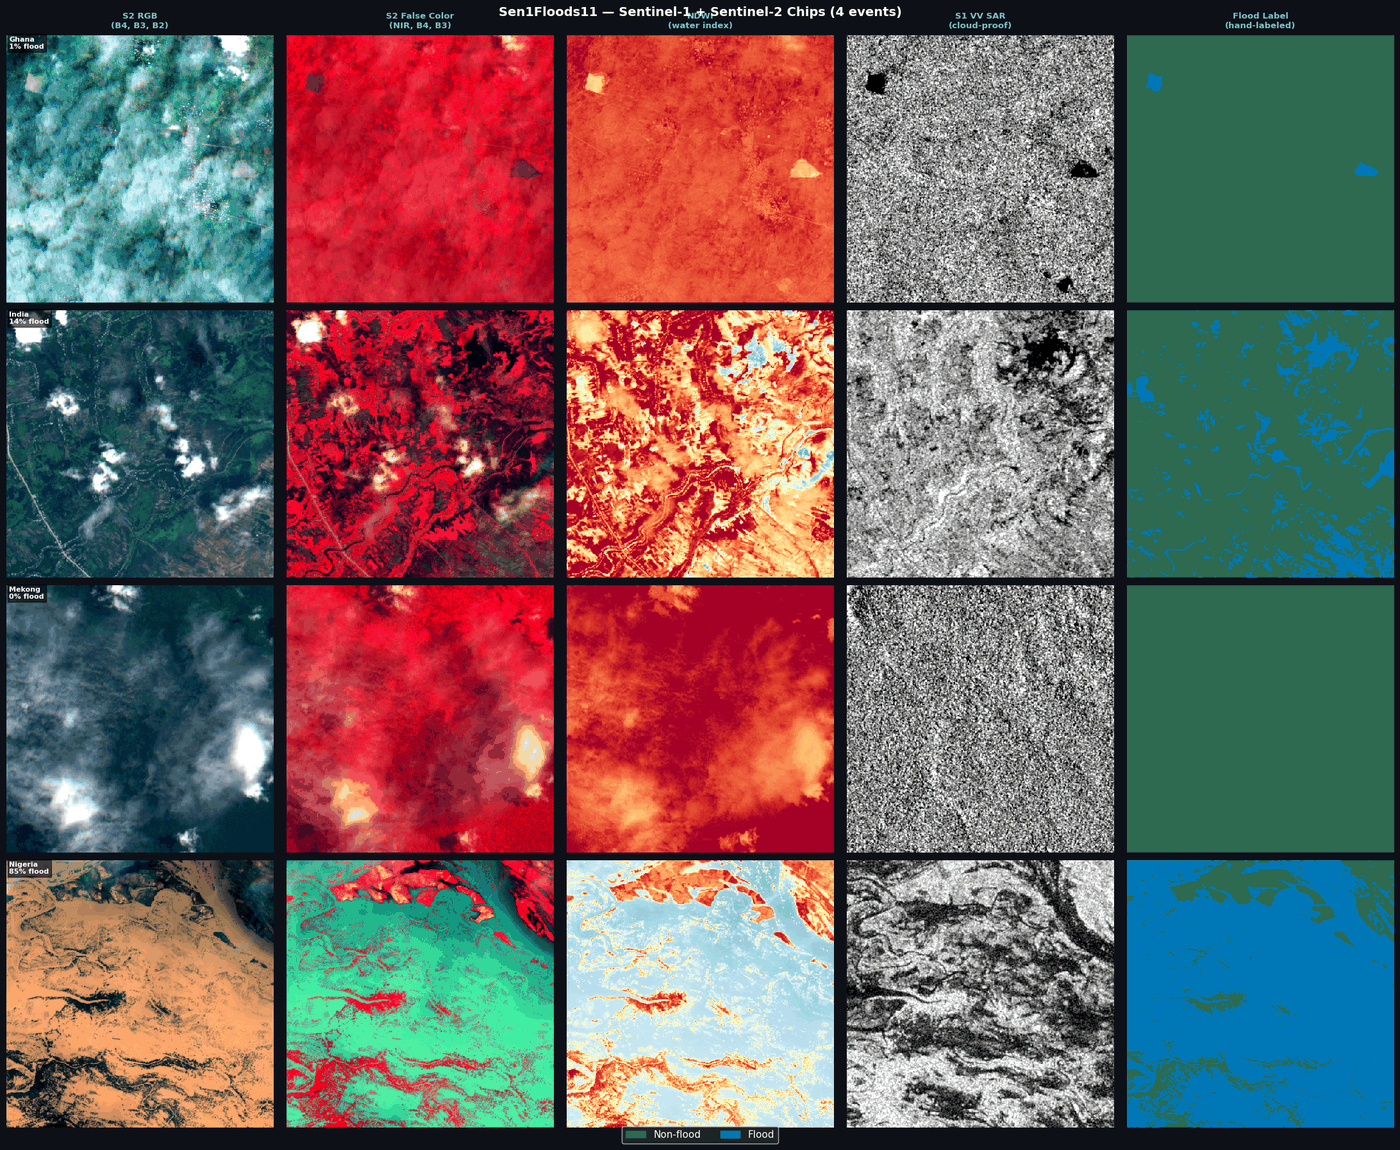

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

def pct_stretch(arr, lo=2, hi=98):
    a, b = np.percentile(arr, [lo, hi])
    return np.clip((arr - a) / (b - a + 1e-8), 0, 1)

def load_chip(name):
    with rasterio.open(f"{S2_DIR}/{name}_S2Hand.tif")  as f: s2  = f.read().astype(np.float32)
    with rasterio.open(f"{S1_DIR}/{name}_S1Hand.tif")  as f: s1  = f.read().astype(np.float32)
    with rasterio.open(f"{LBL_DIR}/{name}_LabelHand.tif") as f: lbl = f.read(1).astype(np.int16)
    return s2, s1, lbl

FLOOD_CMAP = ListedColormap(["#2d6a4f", "#0077b6"])  # green=land, blue=flood

# Pick chips from 4 different events for diversity
sample_events = {}
for name in TRAIN_NAMES:
    ev = name.split("_")[0]
    if ev not in sample_events:
        sample_events[ev] = name
    if len(sample_events) == 4:
        break
samples = list(sample_events.values())

fig, axes = plt.subplots(4, 5, figsize=(22, 18))
fig.patch.set_facecolor("#0d1117")
col_titles = [
    "S2 RGB\n(B4, B3, B2)",
    "S2 False Color\n(NIR, B4, B3)",
    "NDWI\n(water index)",
    "S1 VV SAR\n(cloud-proof)",
    "Flood Label\n(hand-labeled)"
]
for row, name in enumerate(samples):
    s2, s1, lbl = load_chip(name)
    event = name.split("_")[0]

    rgb  = pct_stretch(np.stack([s2[3], s2[2], s2[1]], -1))
    fc   = pct_stretch(np.stack([s2[7], s2[3], s2[2]], -1))
    ndwi = (s2[2] - s2[7]) / (s2[2] + s2[7] + 1e-8)
    vv   = pct_stretch(s1[0])
    mask = np.where(lbl >= 0, lbl, 0).astype(float)

    for col, (img, cm, vn, vx) in enumerate([
        (rgb,  None,      None,  None),
        (fc,   None,      None,  None),
        (ndwi, "RdYlBu", -0.5,   0.5),
        (vv,   "gray",    None,  None),
        (mask, FLOOD_CMAP, 0,     1),
    ]):
        ax = axes[row, col]
        ax.set_facecolor("#161b22")
        ax.imshow(img, cmap=cm, vmin=vn, vmax=vx, interpolation="nearest")
        ax.axis("off")
        if row == 0:
            ax.set_title(col_titles[col], color="#80cbc4",
                         fontsize=9.5, fontweight="bold", pad=8)

    flood_pct = (lbl == 1).mean() * 100
    axes[row, 0].text(5, 25, f"{event}\n{flood_pct:.0f}% flood",
                     color="white", fontsize=8, fontweight="bold",
                     bbox=dict(fc="black", alpha=0.6, pad=2))

patches = [mpatches.Patch(color="#2d6a4f", label="Non-flood"),
           mpatches.Patch(color="#0077b6", label="Flood")]
fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=11,
           facecolor="#21262d", labelcolor="white", bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Sen1Floods11 — Sentinel-1 + Sentinel-2 Chips (4 events)",
             color="white", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sen1floods11_chips.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()


---
# 📡 Step 2 — Spectral Signatures of Flood vs Non-Flood

Before building a model, we should understand **what flood pixels look like**
across sensors. This is the domain knowledge that motivates the model design.


Flood pixels: 3,900  |  Non-flood: 8,700


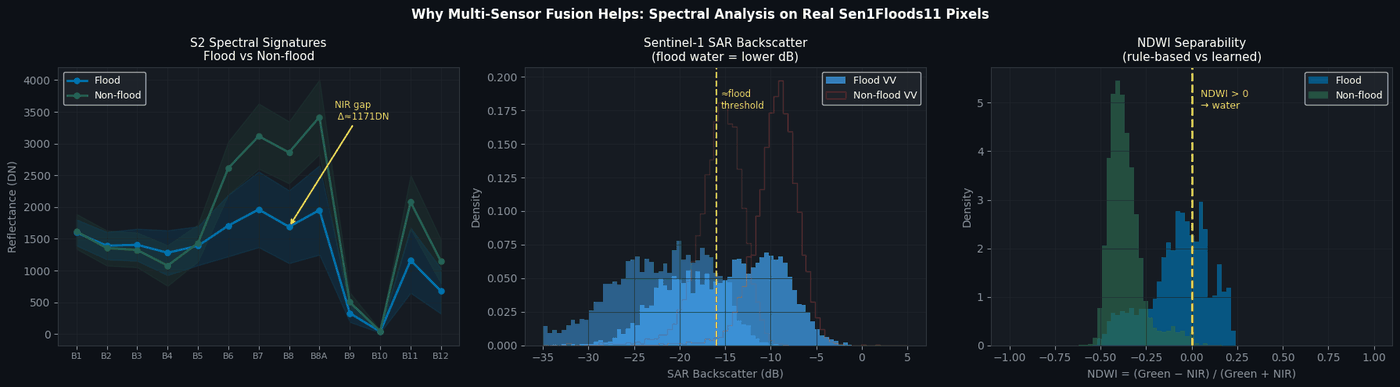

Key takeaways:
  S2 NIR (B8): flood << non-flood (water absorbs NIR)
  S1 VV/VH:    flood << non-flood (smooth water = low backscatter)
  NDWI > 0:    classical water rule — but imperfect (shallow water, turbid water)
  → TerraMind learns ALL of this jointly from both sensors


In [ ]:
# Sample flood and non-flood pixels from training chips
np.random.seed(42)
flood_s2, nonfld_s2 = [], []
flood_s1, nonfld_s1 = [], []

for name in TRAIN_NAMES[:30]:
    s2, s1, lbl = load_chip(name)
    fm  = lbl == 1
    nfm = lbl == 0
    for arr, masks, store in [(s2, (fm, nfm), (flood_s2, nonfld_s2)),
                               (s1, (fm, nfm), (flood_s1, nonfld_s1))]:
        for mask, out in zip(masks, store):
            ys, xs = np.where(mask)
            if len(ys) > 50:
                idx = np.random.choice(len(ys), min(300, len(ys)), replace=False)
                out.append(arr[:, ys[idx], xs[idx]].T)

F_S2 = np.concatenate(flood_s2)
N_S2 = np.concatenate(nonfld_s2)
F_S1 = np.concatenate(flood_s1)
N_S1 = np.concatenate(nonfld_s1)
print(f"Flood pixels: {len(F_S2):,}  |  Non-flood: {len(N_S2):,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0d1117")
bnames = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B10","B11","B12"]

# ── Panel 1: S2 mean spectrum ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#161b22")
x = np.arange(13)
for arr, color, label in [(F_S2, "#0077b6", "Flood"), (N_S2, "#2d6a4f", "Non-flood")]:
    m, s = arr.mean(0), arr.std(0)
    ax.plot(x, m, "o-", color=color, lw=2, ms=5, label=label)
    ax.fill_between(x, m-s, m+s, alpha=.15, color=color)
ax.set_xticks(x); ax.set_xticklabels(bnames, fontsize=8, color="#8b949e")
ax.set_ylabel("Reflectance (DN)", color="#8b949e")
ax.set_title("S2 Spectral Signatures\nFlood vs Non-flood",
             color="white", fontsize=11)
ax.legend(facecolor="#21262d", labelcolor="white", fontsize=9)
ax.tick_params(colors="#8b949e"); ax.grid(True, color="#21262d", lw=.5)
for s in ax.spines.values(): s.set_color("#30363d")
# Key insight annotation
nir_diff = N_S2.mean(0)[7] - F_S2.mean(0)[7]
ax.annotate(f"NIR gap\n Δ≈{nir_diff:.0f}DN", xy=(7, F_S2.mean(0)[7]),
            xytext=(8.5, F_S2.mean(0)[7]*2),
            color="#ffd700", fontsize=8.5,
            arrowprops=dict(arrowstyle="->", color="#ffd700", lw=1.5))

# ── Panel 2: SAR backscatter distributions ───────────────────────────────────
ax = axes[1]
ax.set_facecolor("#161b22")
bins = np.linspace(-35, 5, 80)
for band_i, bname in enumerate(["VV", "VH"]):
    alpha_f, alpha_n = (0.7, 0.3) if band_i==0 else (0.5, 0.2)
    ax.hist(F_S1[:, band_i].clip(-40,5), bins=bins, alpha=alpha_f,
            color="#42a5f5", density=True,
            label=f"Flood {bname}" if band_i==0 else "_")
    ax.hist(N_S1[:, band_i].clip(-40,5), bins=bins, alpha=alpha_n,
            color="#ef5350", density=True,
            label=f"Non-flood {bname}" if band_i==0 else "_",
            histtype="step", lw=2)
ax.axvline(-16, color="#ffd700", lw=1.5, ls="--")
ax.text(-15.5, ax.get_ylim()[1]*0.85, "≈flood\nthreshold",
        color="#ffd700", fontsize=8.5)
ax.set_xlabel("SAR Backscatter (dB)", color="#8b949e")
ax.set_ylabel("Density", color="#8b949e")
ax.set_title("Sentinel-1 SAR Backscatter\n(flood water = lower dB)",
             color="white", fontsize=11)
ax.legend(facecolor="#21262d", labelcolor="white", fontsize=9)
ax.tick_params(colors="#8b949e"); ax.grid(True, color="#21262d", lw=.5)
for s in ax.spines.values(): s.set_color("#30363d")

# ── Panel 3: NDWI separability ───────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor("#161b22")
ndwi_f  = (F_S2[:,2] - F_S2[:,7]) / (F_S2[:,2] + F_S2[:,7] + 1e-8)
ndwi_nf = (N_S2[:,2] - N_S2[:,7]) / (N_S2[:,2] + N_S2[:,7] + 1e-8)
bins2 = np.linspace(-1, 1, 80)
ax.hist(ndwi_f,  bins=bins2, alpha=.65, color="#0077b6", label="Flood",     density=True)
ax.hist(ndwi_nf, bins=bins2, alpha=.65, color="#2d6a4f", label="Non-flood", density=True)
ax.axvline(0, color="#ffd700", lw=2, ls="--")
ax.text(0.05, ax.get_ylim()[1]*0.85, "NDWI > 0\n→ water", color="#ffd700", fontsize=9)
ax.set_xlabel("NDWI = (Green − NIR) / (Green + NIR)", color="#8b949e")
ax.set_ylabel("Density", color="#8b949e")
ax.set_title("NDWI Separability\n(rule-based vs learned)",
             color="white", fontsize=11)
ax.legend(facecolor="#21262d", labelcolor="white", fontsize=9)
ax.tick_params(colors="#8b949e"); ax.grid(True, color="#21262d", lw=.5)
for s in ax.spines.values(): s.set_color("#30363d")

fig.suptitle("Why Multi-Sensor Fusion Helps: Spectral Analysis on Real Sen1Floods11 Pixels",
             color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("spectral_analysis.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Key takeaways:")
print("  S2 NIR (B8): flood << non-flood (water absorbs NIR)")
print("  S1 VV/VH:    flood << non-flood (smooth water = low backscatter)")
print("  NDWI > 0:    classical water rule — but imperfect (shallow water, turbid water)")
print("  → TerraMind learns ALL of this jointly from both sensors")


---
# 🧠 Step 3 — Load TerraMind via TerraTorch

## TerraMind architecture overview

```
Input dict → {"S2L1C": [B,13,H,W],  "S1GRD": [B,2,H,W]}
                    ↓
         Modality-specific patch embedders (16×16 patches)
                    ↓
         Shared 12-layer ViT Transformer (pre-trained on 9M samples)
                    ↓
         12 intermediate token tensors: [B, N_patches, embed_dim]
                    ↓ Neck
    SelectIndices → ReshapeTokensToImage → LearnedInterpolateToPyramidal
         (4 spatial feature maps at different resolutions)
                    ↓ Decoder (trainable)
              UNetDecoder [256, 128, 64, 32]
                    ↓ Head
              Conv2d → [B, 2, H, W]  (flood / non-flood)
```

## TerraMind model sizes

| Model | Params | Min VRAM | Colab T4? |
|-------|--------|----------|-----------|
| `terramind_v1_tiny`  | ~28M  | 4 GB  | ✅ yes |
| `terramind_v1_small` | ~90M  | 8 GB  | ✅ yes (16 GB T4) |
| `terramind_v1_base`  | ~300M | 16 GB | ✅ T4 with fp16 |
| `terramind_v1_large` | ~1.2B | 40 GB | ❌ need A100 |

Weights auto-download from `ibm-esa-geospatial/TerraMind-1.0-small` on HuggingFace.


In [ ]:
from terratorch.registry import TERRATORCH_BACKBONE_REGISTRY
BACKBONE = "terramind_v1_small"   # good default
# BACKBONE = "terramind_v1_tiny"  # faster / lighter
# BACKBONE = "terramind_v1_base"  # heavier / better
# List available TerraMind variants
tm_variants = sorted([k for k in TERRATORCH_BACKBONE_REGISTRY if "terramind" in k.lower()])
print("Available TerraMind backbones:")
for v in tm_variants:
    print(f"  {v}")

# Load the backbone encoder (weights from HuggingFace, auto-download ~350 MB for small)
print(f"\nLoading {BACKBONE} pretrained backbone...")
print("(First run downloads weights from HuggingFace — ~350 MB for small, ~100 MB for tiny)")

backbone = TERRATORCH_BACKBONE_REGISTRY.build(
    BACKBONE,
    pretrained=True,
    modalities=["S2L1C", "S1GRD"],   # both sensors
)
backbone.eval()

n_total = sum(p.numel() for p in backbone.parameters())
print(f"\n✅ {BACKBONE} loaded")
print(f"   Parameters: {n_total/1e6:.1f}M")
print(f"   Modalities: S2L1C (13 bands) + S1GRD (2 bands)")

# Quick forward pass to confirm shapes
dummy = {
    "S2L1C": torch.randn(1, 13, 224, 224),
    "S1GRD": torch.randn(1,  2, 224, 224),
}
backbone = backbone
with torch.no_grad():
    tokens = backbone(dummy)

print(f"\nForward pass: input (1,13,224,224)+(1,2,224,224)")
print(f"Output: list of {len(tokens)} token tensors:")
for i, t in enumerate(tokens):
    print(f"  Layer {i:>2}: {list(t.shape)}")
print("\n↑ These flat token sequences → Neck → spatial feature maps → Decoder")


Available TerraMind backbones:
  terramind_v01_base
  terramind_v01_base_tim
  terramind_v1_base
  terramind_v1_base_tim
  terramind_v1_large
  terramind_v1_large_tim
  terramind_v1_small
  terramind_v1_small_tim
  terramind_v1_tiny
  terramind_v1_tiny_tim
  terramind_v1_tokenizer_dem
  terramind_v1_tokenizer_lulc
  terramind_v1_tokenizer_ndvi
  terramind_v1_tokenizer_s1grd
  terramind_v1_tokenizer_s1rtc
  terramind_v1_tokenizer_s2l2a

Loading terramind_v1_small pretrained backbone...
(First run downloads weights from HuggingFace — ~350 MB for small, ~100 MB for tiny)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


TerraMind_v1_small.pt:   0%|          | 0.00/504M [00:00<?, ?B/s]


✅ terramind_v1_small loaded
   Parameters: 22.8M
   Modalities: S2L1C (13 bands) + S1GRD (2 bands)

Forward pass: input (1,13,224,224)+(1,2,224,224)
Output: list of 12 token tensors:
  Layer  0: [1, 196, 384]
  Layer  1: [1, 196, 384]
  Layer  2: [1, 196, 384]
  Layer  3: [1, 196, 384]
  Layer  4: [1, 196, 384]
  Layer  5: [1, 196, 384]
  Layer  6: [1, 196, 384]
  Layer  7: [1, 196, 384]
  Layer  8: [1, 196, 384]
  Layer  9: [1, 196, 384]
  Layer 10: [1, 196, 384]
  Layer 11: [1, 196, 384]

↑ These flat token sequences → Neck → spatial feature maps → Decoder


---
# 📦 Step 4 — Configure the Multimodal DataModule

`GenericMultiModalDataModule` is TerraTorch's Lightning DataModule for
datasets with multiple sensor modalities. Key things it handles:

- **Multi-modal loading**: reads S2 and S1 TIFFs as a paired dict per chip
- **Normalization**: applies per-modality mean/std (we use TerraMind's pre-training stats)
- **Augmentation**: D4 (random flip + 90° rotation) applied consistently to all modalities + label
- **Split management**: reads train/val/test chip names from `.txt` files
- **No-data handling**: `ignore_index=-1` skips cloudy/edge pixels in the loss

> ⚠️ **Important**: Use TerraMind's **pre-training normalization stats**, not
> stats computed from Sen1Floods11. The model expects the same distribution
> it was trained on.


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from terratorch.datamodules import GenericMultiModalDataModule

# ── TerraMind pre-training normalization statistics ───────────────────────────
MEANS = {
    "S2L1C": [
        2357.089, 2137.385, 2018.788, 2082.986, 2295.651,
        2854.537, 3122.849, 3040.560, 3306.481, 1473.847,
        506.070, 2472.825, 1838.929
    ],
    "S1GRD": [-12.599, -20.293],
}

STDS = {
    "S2L1C": [
        1624.683, 1675.806, 1557.708, 1833.702, 1823.738,
        1733.977, 1732.131, 1679.732, 1727.260, 1024.687,
        442.165, 1331.411, 1160.419
    ],
    "S1GRD": [5.195, 5.890],
}

DATA_ROOT = "sen1floods11_v1.1"

datamodule = GenericMultiModalDataModule(
    task="segmentation",
    num_classes=2,
    batch_size=4,      # reduce to 2 if you hit OOM
    num_workers=2,

    # Modalities
    modalities=["S2L1C", "S1GRD"],

    # Visualization config
    rgb_indices={"S2L1C": [3, 2, 1]},   # B4, B3, B2

    # Data roots
    train_data_root={
        "S2L1C": f"{DATA_ROOT}/data/S2L1CHand",
        "S1GRD": f"{DATA_ROOT}/data/S1GRDHand",
    },
    val_data_root={
        "S2L1C": f"{DATA_ROOT}/data/S2L1CHand",
        "S1GRD": f"{DATA_ROOT}/data/S1GRDHand",
    },
    test_data_root={
        "S2L1C": f"{DATA_ROOT}/data/S2L1CHand",
        "S1GRD": f"{DATA_ROOT}/data/S1GRDHand",
    },

    # Label roots
    train_label_data_root=f"{DATA_ROOT}/data/LabelHand",
    val_label_data_root=f"{DATA_ROOT}/data/LabelHand",
    test_label_data_root=f"{DATA_ROOT}/data/LabelHand",

    # Split files
    train_split=f"{DATA_ROOT}/splits/flood_train_data.txt",
    val_split=f"{DATA_ROOT}/splits/flood_valid_data.txt",
    test_split=f"{DATA_ROOT}/splits/flood_test_data.txt",

    # File patterns
    image_grep={
        "S2L1C": "*_S2Hand.tif",
        "S1GRD": "*_S1Hand.tif",
    },
    label_grep="*_LabelHand.tif",

    # Missing/no-data handling
    no_label_replace=-1,
    no_data_replace=0,

    # Pretraining normalization
    means=MEANS,
    stds=STDS,

    # Augmentations
    train_transform=[
        A.D4(),
        ToTensorV2(),
    ],
    val_transform=[
        ToTensorV2(),
    ],
    test_transform=[
        ToTensorV2(),
    ],
)

# Build datasets
datamodule.setup("fit")
datamodule.setup("test")

print("✅ DataModule configured")
print(f"   Train : {len(datamodule.train_dataset)} chips")
print(f"   Val   : {len(datamodule.val_dataset)} chips")
print(f"   Test  : {len(datamodule.test_dataset)} chips")

# Quick batch sanity check
batch = next(iter(datamodule.train_dataloader()))
print("\nBatch keys:", batch.keys())

# Print structure safely
if "image" in batch:
    print("Image modalities:", batch["image"].keys())
    print("S2L1C shape:", batch["image"]["S2L1C"].shape)
    print("S1GRD shape:", batch["image"]["S1GRD"].shape)

if "mask" in batch:
    print("Mask shape:", batch["mask"].shape)
elif "label" in batch:
    print("Label shape:", batch["label"].shape)

✅ DataModule configured
   Train : 252 chips
   Val   : 89 chips
   Test  : 90 chips

Batch keys: dict_keys(['mask', 'image', 'filename'])
Image modalities: dict_keys(['S2L1C', 'S1GRD'])
S2L1C shape: torch.Size([4, 13, 512, 512])
S1GRD shape: torch.Size([4, 2, 512, 512])
Mask shape: torch.Size([4, 512, 512])


In [ ]:
# ── Inspect one batch from the dataloader ────────────────────────────────────
loader = datamodule.train_dataloader()
batch  = next(iter(loader))

print("Batch structure:")
print(f"  batch['image'] keys : {list(batch['image'].keys())}")
print(f"  S2L1C shape         : {batch['image']['S2L1C'].shape}  ← [B, 13, H, W]")
print(f"  S1GRD shape         : {batch['image']['S1GRD'].shape}   ← [B,  2, H, W]")
print(f"  mask  shape         : {batch['mask'].shape}")
print()
print(f"  S2 normalised range : [{batch['image']['S2L1C'].min():.2f}, {batch['image']['S2L1C'].max():.2f}]")
print(f"  S1 normalised range : [{batch['image']['S1GRD'].min():.2f}, {batch['image']['S1GRD'].max():.2f}]")
print()

vals, cts = batch['mask'].unique(return_counts=True)
total = batch['mask'].numel()
print("  Label distribution:")
for v, c in zip(vals.tolist(), cts.tolist()):
    name = {-1:"no-data", 0:"non-flood", 1:"flood"}.get(v, str(v))
    print(f"    {v:>2}  ({name:<10})  {c:>7,} px  ({c/total:.1%})")


Batch structure:
  batch['image'] keys : ['S2L1C', 'S1GRD']
  S2L1C shape         : torch.Size([4, 13, 512, 512])  ← [B, 13, H, W]
  S1GRD shape         : torch.Size([4, 2, 512, 512])   ← [B,  2, H, W]
  mask  shape         : torch.Size([4, 512, 512])

  S2 normalised range : [8.00, 6384.00]
  S1 normalised range : [-60.44, 15.53]

  Label distribution:
    -1  (no-data   )   15,638 px  (1.5%)
     0  (non-flood )  746,939 px  (71.2%)
     1  (flood     )  285,999 px  (27.3%)


---
# 🚀 Step 5 — Fine-tune TerraMind

## Architecture choices

**Backbone (frozen):** TerraMind's pre-trained ViT encoder.
We freeze it so it doesn't overfit the small Sen1Floods11 training set (~300 chips).

**Neck (trainable):** Three-stage pipeline that converts flat ViT tokens to
a spatial feature pyramid needed by the UNet decoder:
1. `SelectIndices([2,5,8,11])` — picks 4 evenly-spaced block outputs
2. `ReshapeTokensToImage` — reshapes `[B, N, D]` → `[B, D, H/16, W/16]`
3. `LearnedInterpolateToPyramidal` — learns to upsample to 4 scales

**Decoder (trainable):** UNetDecoder with skip connections at 4 scales.

**Loss:** Dice loss — directly optimises IoU overlap, handles class imbalance
better than cross-entropy (flood pixels are rare, often <20% per chip).

## Fine-tuning recipe (from IBM paper)
- LR: `2e-5` with ReduceLROnPlateau (patience=5, factor=0.5)
- Batch: 8 (we use 4 on free T4)
- Epochs: 100 for full training; 5 for this demo
- Expected 5-epoch mIoU: ~0.55–0.65 (full training: ~0.79)


In [ ]:
from terratorch.tasks import SemanticSegmentationTask

model = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args={
        # ── Backbone ──────────────────────────────────────────────────
        "backbone"            : BACKBONE,
        "backbone_pretrained" : True,
        "backbone_modalities" : ["S2L1C", "S1GRD"],
        "backbone_merge_method": "mean",         # how to merge S2+S1 tokens

        # ── Neck (ViT tokens → spatial pyramid) ───────────────────────
        # IMPORTANT: remove_cls_token=False because TerraMind has NO CLS token
        "necks": [
            {"name": "SelectIndices", "indices": [2, 5, 8, 11]},
            {"name": "ReshapeTokensToImage", "remove_cls_token": False},
            {"name": "LearnedInterpolateToPyramidal"},
        ],

        # ── Decoder ───────────────────────────────────────────────────
        "decoder"          : "UNetDecoder",
        "decoder_channels" : [256, 128, 64, 32],

        # ── Head ──────────────────────────────────────────────────────
        "head_dropout" : 0.1,
        "num_classes"  : 2,               # 0=other, 1=flood
    },

    # ── Loss ────────────────────────────────────────────────────────────
    loss="dice",
    ignore_index=-1,                       # skip -1 (cloud/no-data) pixels

    # ── Freeze strategy ─────────────────────────────────────────────────
    freeze_backbone=True,                  # backbone: frozen (pre-trained)
    freeze_decoder=False,                  # decoder + head: trainable

    # ── Optimiser ───────────────────────────────────────────────────────
    optimizer="AdamW",
    lr=2e-5,

    # ── Misc ────────────────────────────────────────────────────────────
    class_names=["Other", "Flood"],
    plot_on_val=True,
)

total     = sum(p.numel() for p in model.parameters())
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = total - frozen

print(f"✅ SemanticSegmentationTask built")
print(f"   Total params          : {total/1e6:.1f}M")
print(f"   Frozen (backbone)     : {frozen/1e6:.1f}M")
print(f"   Trainable (decoder+head): {trainable/1e6:.2f}M")
print(f"\n   Strategy: pre-trained backbone FROZEN, only decoder/head trained")
print(f"   This prevents catastrophic forgetting + works well with ~300 training chips")


✅ SemanticSegmentationTask built
   Total params          : 26.6M
   Frozen (backbone)     : 22.8M
   Trainable (decoder+head): 3.88M

   Strategy: pre-trained backbone FROZEN, only decoder/head trained
   This prevents catastrophic forgetting + works well with ~300 training chips


In [ ]:
import os
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor, RichProgressBar
from lightning.pytorch.loggers import TensorBoardLogger

os.makedirs("output/checkpoints", exist_ok=True)

# Monitor val mIoU — TerraTorch logs it as 'val/Multiclass_Jaccard_Index'
checkpoint_cb = ModelCheckpoint(
    dirpath="output/checkpoints/",
    filename="best-mIoU",
    monitor="val/mIoU",
    mode="max",
    save_top_k=1,
    verbose=True,
)

trainer = pl.Trainer(
    accelerator="auto",
    devices="auto",
    precision="16-mixed",    # fp16 halves VRAM use — essential on free T4
    max_epochs=20,            # ← demo: 5 epochs. For real results use 50-100
    log_every_n_steps=5,
    callbacks=[checkpoint_cb, LearningRateMonitor("epoch"), RichProgressBar()],
    logger=TensorBoardLogger("output/", name="tb_logs"),
    default_root_dir="output/",
)

print(f"✅ Trainer configured")
print(f"   Precision : 16-mixed")
print(f"   Epochs    : {trainer.max_epochs}  (increase to 50-100 for research quality)")
print(f"   Checkpoint: output/checkpoints/best-mIoU.ckpt")
print()
print("📊 Optional: load TensorBoard extension")
print("   %load_ext tensorboard")
print("   %tensorboard --logdir output/tb_logs")


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer configured
   Precision : 16-mixed
   Epochs    : 20  (increase to 50-100 for research quality)
   Checkpoint: output/checkpoints/best-mIoU.ckpt

📊 Optional: load TensorBoard extension
   %load_ext tensorboard
   %tensorboard --logdir output/tb_logs


In [ ]:
# ── Fine-tune TerraMind ───────────────────────────────────────────────────────
# ~5-8 min per epoch on T4 GPU (5 epochs ≈ 25-40 min)
# Expected val mIoU after 5 epochs: ~0.55-0.65
# Expected val mIoU after 100 epochs: ~0.79 (IBM paper, terramind_v1_small)

print("🚀 Starting fine-tuning...")
trainer.fit(model, datamodule=datamodule)

best_ckpt = checkpoint_cb.best_model_path
best_score = checkpoint_cb.best_model_score
print(f"\n✅ Training complete")
print(f"   Best checkpoint : {best_ckpt}")
print(f"   Best val mIoU   : {float(best_score):.4f}")
print()
print("Note: 5-epoch results are a demo. For publication-quality results:")
print("  trainer.max_epochs = 100  (or use CLI: terratorch fit -c config.yaml)")


🚀 Starting fine-tuning...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │ 26.6 M │ train │     0 │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 3.9 M                                                                                            
Non-trainable params: 22.8 M                                                                                       
Total params: 26.6 M                                                                                               
Total estimated model params size (MB): 106                                                                        
Modules in train mode: 290                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: Epoch 0, global step 63: 'val/mIoU' reached 0.66688 (best 0.66688), saving model to '/content/output/checkpoints/best-mIoU.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 63: 'val/mIoU' reached 0.66688 (best 0.66688), saving model to '/content/output/checkpoints/best-mIoU.ckpt' as top 1
INFO: Epoch 1, global step 126: 'val/mIoU' reached 0.73755 (best 0.73755), saving model to '/content/output/checkpoints/best-mIoU.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 126: 'val/mIoU' reached 0.73755 (best 0.73755), saving model to '/content/output/checkpoints/best-mIoU.ckpt' as top 1
INFO: Epoch 2, global step 189: 'val/mIoU' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 2, global step 189: 'val/mIoU' was not in top 1
INFO: Epoch 3, global step 252: 'val/mIoU' reached 0.76989 (best 0.76989), saving model to '/content/output/checkpoints/best-mIoU.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epo


✅ Training complete
   Best checkpoint : /content/output/checkpoints/best-mIoU.ckpt
   Best val mIoU   : 0.8368

Note: 5-epoch results are a demo. For publication-quality results:
  trainer.max_epochs = 100  (or use CLI: terratorch fit -c config.yaml)


---
# 📊 Step 6 — Evaluation & Visualisation


---
# 📊 Evaluation

## Segmentation Metrics Explained

For semantic segmentation, we use:

$$\text{IoU}_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FP}_c + \text{FN}_c}$$

$$\text{mIoU} = \frac{1}{K}\sum_{c=1}^{K} \text{IoU}_c$$

$$\text{F1}_c = \frac{2 \cdot \text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

| Metric | What it measures | Range |
|--------|-----------------|-------|
| **IoU** | Overlap between pred and GT | 0–1 (higher=better) |
| **mIoU** | Average IoU across all classes | 0–1 |
| **F1** | Harmonic mean of P & R | 0–1 |
| **Accuracy** | Fraction correctly classified | 0–1 (misleading for imbalanced data!) |


In [ ]:
# ── Test set evaluation ───────────────────────────────────────────────────────
best_ckpt = "output/checkpoints/best-mIoU.ckpt"
results = trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt)

print("\nTest set results:")
for k, v in sorted(results[0].items()):
    print(f"  {k:<45} {v:.4f}")


INFO: Restoring states from the checkpoint path at output/checkpoints/best-mIoU.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at output/checkpoints/best-mIoU.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at output/checkpoints/best-mIoU.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at output/checkpoints/best-mIoU.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.9256576895713806     │
│    test/Boundary_mIoU     │    0.12870778143405914    │
│ test/Class_Accuracy_Flood │     0.881703794002533     │
│ test/Class_Accuracy_Other │    0.9696115851402283     │
│       test/F1_Score       │    0.9090993404388428     │
│      test/IoU_Flood       │     0.727128267288208     │
│      test/IoU_Other       │    0.9534878134727478     │
│    test/Pixel_Accuracy    │    0.9586169123649597     │
│         test/loss         │    0.2933576703071594     │
│         test/mIoU         │    0.8403080701828003     │
│      test/mIoU_Micro      │    0.9205228090286255     │
└───────────────────────────┴───────────────────────────┘


Test set results:
  test/Accuracy                                 0.9257
  test/Boundary_mIoU                            0.1287
  test/Class_Accuracy_Flood                     0.8817
  test/Class_Accuracy_Other                     0.9696
  test/F1_Score                                 0.9091
  test/IoU_Flood                                0.7271
  test/IoU_Other                                0.9535
  test/Pixel_Accuracy                           0.9586
  test/loss                                     0.2934
  test/mIoU                                     0.8403
  test/mIoU_Micro                               0.9205


In [ ]:
# ── Load best model for visualisation ────────────────────────────────────────
inf_model = SemanticSegmentationTask.load_from_checkpoint(
    "output/checkpoints/best-mIoU.ckpt",
    model_factory=model.hparams["model_factory"],
    model_args=model.hparams["model_args"],
)
inf_model.eval()
print(f"✅ Model loaded for inference on")


✅ Model loaded for inference on


In [ ]:
# ============================================================
# Minimal UNet training (Sen1Floods11, S2 only)
# ============================================================

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, rasterio
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ── Dataset ───────────────────────────────────────────────
class FloodS2Dataset(Dataset):
    S2_MEANS = torch.tensor([2357.089,2137.385,2018.788,2082.986,2295.651,
                             2854.537,3122.849,3040.560,3306.481,1473.847,
                             506.070,2472.825,1838.929])
    S2_STDS  = torch.tensor([1624.683,1675.806,1557.708,1833.702,1823.738,
                             1733.977,1732.131,1679.732,1727.260,1024.687,
                             442.165,1331.411,1160.419])

    def __init__(self, names, s2_dir, lbl_dir):
        self.names, self.s2_dir, self.lbl_dir = names, s2_dir, lbl_dir

    def __len__(self): return len(self.names)

    def __getitem__(self, idx):
        n = self.names[idx]

        with rasterio.open(f'{self.s2_dir}/{n}_S2Hand.tif') as f:
            s2 = torch.FloatTensor(f.read().astype(np.float32))

        with rasterio.open(f'{self.lbl_dir}/{n}_LabelHand.tif') as f:
            lbl = torch.LongTensor(f.read(1).astype(np.int64))

        s2 = (s2 - self.S2_MEANS[:, None, None]) / (self.S2_STDS[:, None, None] + 1e-8)
        return s2, lbl


# ── UNet ─────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(),
            nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=13, n_cls=2):
        super().__init__()
        self.down1 = DoubleConv(in_ch, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.head = nn.Conv2d(64, n_cls, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))

        b = self.bottleneck(self.pool(d3))

        x = self.up3(b)
        x = self.conv3(torch.cat([x, d3], dim=1))

        x = self.up2(x)
        x = self.conv2(torch.cat([x, d2], dim=1))

        x = self.up1(x)
        x = self.conv1(torch.cat([x, d1], dim=1))

        return self.head(x)


# ── Loss + IoU ───────────────────────────────────────────
def dice_loss(logits, targets):
    probs = logits.softmax(dim=1)[:, 1]
    p = probs.reshape(-1)
    t = (targets.reshape(-1) == 1).float()
    inter = (p * t).sum()
    return 1 - (2*inter + 1) / (p.sum() + t.sum() + 1)

def iou(pred, gt):
    tp = ((pred==1)&(gt==1)).sum()
    fp = ((pred==1)&(gt==0)).sum()
    fn = ((pred==0)&(gt==1)).sum()
    return tp / (tp + fp + fn + 1e-8)


# ── Data ─────────────────────────────────────────────────
DATA_ROOT = 'sen1floods11_v1.1'
S2_DIR  = f'{DATA_ROOT}/data/S2L1CHand'
LBL_DIR = f'{DATA_ROOT}/data/LabelHand'

train_ld = DataLoader(FloodS2Dataset(TRAIN_NAMES, S2_DIR, LBL_DIR),
                      batch_size=4, shuffle=True)
val_ld   = DataLoader(FloodS2Dataset(VAL_NAMES, S2_DIR, LBL_DIR),
                      batch_size=4)


# ── Train ────────────────────────────────────────────────
model = UNet().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)

EPOCHS = 20

for ep in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_ld:
        x, y = x.to(DEVICE), y.to(DEVICE)

        opt.zero_grad()
        loss = dice_loss(model(x), y)
        loss.backward()
        opt.step()

        total_loss += loss.item()

    # validation IoU
    model.eval()
    ious = []
    with torch.no_grad():
        for x, y in val_ld:
            preds = model(x.to(DEVICE)).argmax(1).cpu()
            for p, g in zip(preds, y):
                ious.append(iou(p.numpy(), g.numpy()))

    print(f"Epoch {ep+1}/{EPOCHS} | Loss: {total_loss/len(train_ld):.4f} | Val mIoU: {np.mean(ious):.4f}")

Epoch 1/20 | Loss: 0.7130 | Val mIoU: 0.3713
Epoch 2/20 | Loss: 0.6282 | Val mIoU: 0.4209
Epoch 3/20 | Loss: 0.5912 | Val mIoU: 0.4098
Epoch 4/20 | Loss: 0.5474 | Val mIoU: 0.4244
Epoch 5/20 | Loss: 0.5436 | Val mIoU: 0.4825
Epoch 6/20 | Loss: 0.4977 | Val mIoU: 0.4248
Epoch 7/20 | Loss: 0.4685 | Val mIoU: 0.4466
Epoch 8/20 | Loss: 0.4580 | Val mIoU: 0.4568
Epoch 9/20 | Loss: 0.4121 | Val mIoU: 0.4597
Epoch 10/20 | Loss: 0.3850 | Val mIoU: 0.4838
Epoch 11/20 | Loss: 0.3674 | Val mIoU: 0.4914
Epoch 12/20 | Loss: 0.3719 | Val mIoU: 0.4899
Epoch 13/20 | Loss: 0.3488 | Val mIoU: 0.4653
Epoch 14/20 | Loss: 0.3493 | Val mIoU: 0.4279
Epoch 15/20 | Loss: 0.3202 | Val mIoU: 0.4879
Epoch 16/20 | Loss: 0.3345 | Val mIoU: 0.4615
Epoch 17/20 | Loss: 0.3292 | Val mIoU: 0.4841
Epoch 18/20 | Loss: 0.3191 | Val mIoU: 0.4974
Epoch 19/20 | Loss: 0.2777 | Val mIoU: 0.4660
Epoch 20/20 | Loss: 0.3062 | Val mIoU: 0.4981


In [ ]:
# ============================================================
# UNet Test Evaluation (run AFTER training cell)
# ============================================================

test_ld = DataLoader(FloodS2Dataset(TEST_NAMES, S2_DIR, LBL_DIR),
                     batch_size=4, shuffle=False)

model.eval()
ious = []

with torch.no_grad():
    for x, y in test_ld:
        preds = model(x.to(DEVICE)).argmax(1).cpu()
        for p, g in zip(preds, y):
            ious.append(iou(p.numpy(), g.numpy()))

test_miou = float(np.mean(ious))

print("\n==============================")
print(f"UNet Test mIoU: {test_miou:.4f}")
print("==============================")


UNet Test mIoU: 0.5370


Filtered samples: 45
Top IoUs: [0.816, 0.814, 0.775, 0.771, 0.768, 0.682, 0.676, 0.675, 0.606, 0.603]


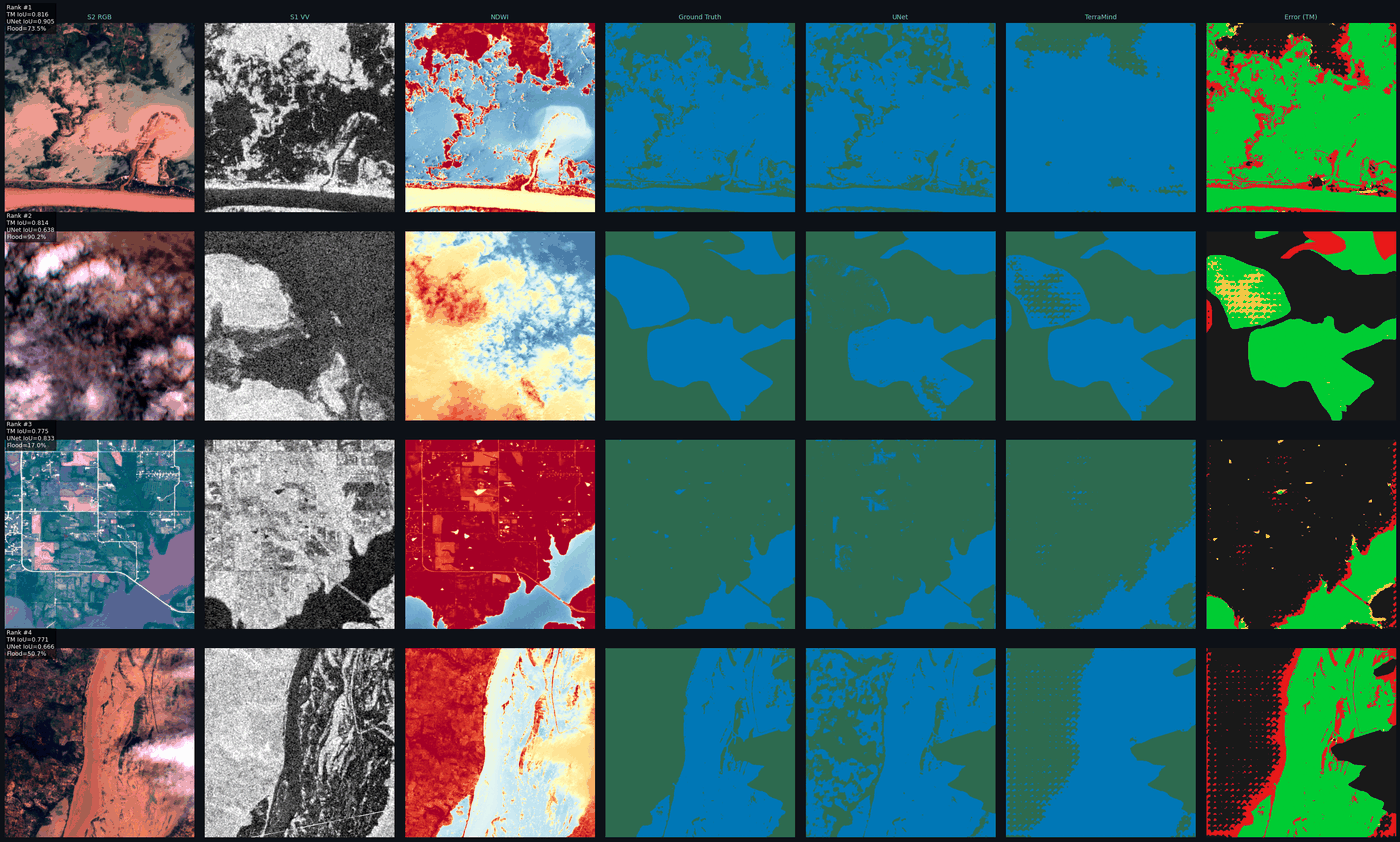

In [ ]:
# --- Add this BEFORE loop ---
unet.eval()

# -------------------------------------------------------------------
# Collect per-chip predictions + IoU
# -------------------------------------------------------------------
all_samples = []

with torch.no_grad():
    for batch in test_loader:
        s2  = batch["image"]["S2L1C"].to(DEVICE)
        s1  = batch["image"]["S1GRD"].to(DEVICE)
        lbl = batch["mask"].to(DEVICE)

        # TerraMind
        out = inf_model.model({"S2L1C": s2, "S1GRD": s1})
        logits = out.output if hasattr(out, "output") else out[0] if isinstance(out, (list, tuple)) else out
        preds_tm = logits.argmax(1).cpu()

        # UNet (S2 only)
        preds_unet = unet(s2).argmax(1).cpu()

        s2_cpu = s2.cpu()
        s1_cpu = s1.cpu()
        lbl_cpu = lbl.cpu()

        for i in range(s2.shape[0]):
            gt = lbl_cpu[i].numpy()
            pred_tm = preds_tm[i].numpy()
            pred_unet = preds_unet[i].numpy()

            valid = gt >= 0

            def compute_iou(pred):
                tp = ((pred==1)&(gt==1)&valid).sum()
                fp = ((pred==1)&(gt==0)&valid).sum()
                fn = ((pred==0)&(gt==1)&valid).sum()
                return tp / (tp + fp + fn + 1e-8)

            iou_tm = compute_iou(pred_tm)
            iou_unet = compute_iou(pred_unet)

            flood_pct = ((gt == 1) & valid).sum() / (valid.sum() + 1e-8)

            all_samples.append({
                "s2": s2_cpu[i],
                "s1": s1_cpu[i],
                "gt": gt,
                "pred_tm": pred_tm,
                "pred_unet": pred_unet,
                "iou_tm": float(iou_tm),
                "iou_unet": float(iou_unet),
                "flood_pct": float(flood_pct),
            })

# -------------------------------------------------------------------
# 🔴 FILTER OUT TRIVIAL CASES (very important)
# -------------------------------------------------------------------
filtered_samples = [
    x for x in all_samples
    if 0.05 < x["iou_tm"] < 0.98   # remove empty + perfect
]

# Sort by TerraMind IoU
filtered_samples = sorted(filtered_samples, key=lambda x: x["iou_tm"], reverse=True)

print(f"Filtered samples: {len(filtered_samples)}")
print("Top IoUs:", [round(x["iou_tm"], 3) for x in filtered_samples[:10]])


# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
n_show = 4
best_samples = filtered_samples[:n_show]

fig, axes = plt.subplots(n_show, 7, figsize=(30, 4.5 * n_show))
fig.patch.set_facecolor("#0d1117")

col_titles = [
    "S2 RGB", "S1 VV", "NDWI",
    "Ground Truth",
    "UNet", "TerraMind",
    "Error (TM)"
]

if n_show == 1:
    axes = np.expand_dims(axes, 0)

for row_i, sample in enumerate(best_samples):
    s2_raw = denorm_s2(sample["s2"])
    s1n    = sample["s1"].numpy()
    lbl    = sample["gt"]
    pred_tm   = sample["pred_tm"]
    pred_unet = sample["pred_unet"]

    iou_tm   = sample["iou_tm"]
    iou_unet = sample["iou_unet"]

    flood_pct = sample["flood_pct"] * 100

    rgb  = pct_stretch(np.stack([s2_raw[3], s2_raw[2], s2_raw[1]], -1))
    vv   = pct_stretch(s1n[0])
    ndwi = (s2_raw[2] - s2_raw[7]) / (s2_raw[2] + s2_raw[7] + 1e-8)

    valid = lbl >= 0

    # TerraMind error map
    err = np.full((*lbl.shape, 3), 0.1)
    err[(lbl == 1) & (pred_tm == 1) & valid] = [0.0, 0.8, 0.2]
    err[(lbl == 0) & (pred_tm == 0) & valid] = [0.1, 0.1, 0.1]
    err[(lbl == 0) & (pred_tm == 1) & valid] = [0.9, 0.1, 0.1]
    err[(lbl == 1) & (pred_tm == 0) & valid] = [0.9, 0.8, 0.0]

    panel_data = [
        (rgb, None, None, None),
        (vv, "gray", None, None),
        (ndwi, "RdYlBu", -0.5, 0.5),
        (np.where(valid, lbl, 0), FLOOD_CMAP, 0, 1),
        (np.where(valid, pred_unet, 0), FLOOD_CMAP, 0, 1),
        (np.where(valid, pred_tm, 0), FLOOD_CMAP, 0, 1),
        (err, None, None, None),
    ]

    for ci, (img, cm, vn, vx) in enumerate(panel_data):
        ax = axes[row_i, ci]
        ax.imshow(img, cmap=cm, vmin=vn, vmax=vx)
        ax.axis("off")
        if row_i == 0:
            ax.set_title(col_titles[ci], color="#80cbc4", fontsize=10)

    axes[row_i, 0].text(
        5, 20,
        f"Rank #{row_i+1}\nTM IoU={iou_tm:.3f}\nUNet IoU={iou_unet:.3f}\nFlood={flood_pct:.1f}%",
        color="white", fontsize=9,
        bbox=dict(fc="black", alpha=0.6, pad=2)
    )

plt.tight_layout()
plt.show()

---
# ⚡ Step 7 — Full Training: TerraTorch CLI

For 100-epoch production results, use TerraTorch's CLI with the official IBM config.
This is how you'd run it on CHTC or any GPU server.


In [ ]:
# ── CLI commands (run in terminal / CHTC, not in notebook)

# Train 100 epochs:
# terratorch fit -c terramind_v1_tiny_sen1floods11.yaml

# Test:
# terratorch test -c terramind_v1_tiny_sen1floods11.yaml --ckpt_path output/.../best-mIoU.ckpt

# Extend in notebook: trainer.max_epochs = 50; trainer.fit(model, datamodule=datamodule)

# ── Benchmark from IBM TerraMind paper ───────────
benchmarks = [
    ('UNet (scratch)',           0.612),
    ('Prithvi-100M',             0.724),
    ('Prithvi-EO-2.0 300M',      0.758),
    ('TerraMind-tiny  100ep',    0.771),
    ('TerraMind-small 100ep',    0.789),
    ('TerraMind-large 100ep',    0.812),
    ('TerraMind-small + TiM',    0.831),
]
print('\n' + '='*55)
print('Expected test mIoU (IBM TerraMind paper, Sen1Floods11)')
print('='*55)
for name, miou in benchmarks:
    bar = chr(9608)*int(miou*28)
    tag = '  <- this lab' if 'small' in name and 'TiM' not in name else ''
    print(f'  {name:<30} {miou:.3f}  {bar}{tag}')
print('='*55)


---
# 💬 Step 8 — Discussion Questions

Answer these in the code cell below. Write as comments or strings.

**Q1 — Sensor complementarity**
Look at your prediction visualisations. Find a chip where NDWI would fail
(e.g. turbid water, cloud shadow, dry river bed) but the model succeeds.
What does S1 SAR provide that NDWI misses?

**Q2 — Frozen vs unfrozen backbone**
We used `freeze_backbone=True`. What would happen if you unfroze the backbone
with only 300 training chips? Try setting `freeze_backbone=False`,
retrain, and compare val mIoU. What does this tell you about data requirements?

**Q3 — Normalization matters**
The MEANS dict uses `2357.089` for B1 (TerraMind pre-training stats).
If you instead computed mean/std from Sen1Floods11 itself (much lower values),
what would the model "see" after normalization? Why would this hurt performance?

**Q4 — Ignore index**
Labels contain -1 pixels (cloud cover, image edges). What would happen
to training if we set `ignore_index=None` instead of `-1`?
What loss values would the model try to minimize for those pixels?

**Q5 — Thinking-in-Modalities**
TerraMind-small + TiM gets +4.2 pp mIoU over standard fine-tuning.
TiM generates an intermediate LULC (land cover) token prediction before
predicting floods. Draw a diagram or write a paragraph explaining WHY
knowing land cover helps distinguish flood water from other dark surfaces.

**Q6 — Real-world generalization**
The 11 flood events span 6 continents with very different landscapes
(tropical forests, deserts, rice paddies, urban areas).
Which geographic/ecological context do you think the model struggles with most?
Use the per-event results or visual patterns to justify your answer.


In [ ]:
answers = {
    "Q1_sensor_complementarity": """
    YOUR ANSWER:
    """,
    "Q2_frozen_vs_unfrozen": """
    YOUR ANSWER:
    (optional: paste mIoU comparison from your experiment)
    """,
    "Q3_normalization": """
    YOUR ANSWER:
    """,
    "Q4_ignore_index": """
    YOUR ANSWER:
    """,
    "Q5_thinking_in_modalities": """
    YOUR ANSWER:
    """,
    "Q6_generalization": """
    YOUR ANSWER:
    """,
}

print("Submission checklist:")
for k, v in answers.items():
    done = "✅" if "YOUR ANSWER" not in v else "⬜"
    print(f"  {done}  {k}")


---
# 🌟 Extension — Thinking-in-Modalities (TiM)

**TiM** is TerraMind's unique capability: during fine-tuning it generates
tokens for a missing modality (e.g. LULC land-cover) as an intermediate step,
then uses both real + generated tokens for the final prediction.

From the IBM paper: standard TerraMind-small gets **mIoU=0.789**,
TerraMind-small+TiM gets **mIoU=0.831** — a +4.2 pp boost with zero extra data.

**The only code change:** add `_tim` to the backbone name.


---
# 📚 Resources

| Resource | Link |
|----------|------|
| TerraMind paper (ICCV 2025) | https://arxiv.org/abs/2504.11171 |
| TerraMind HuggingFace | https://huggingface.co/ibm-esa-geospatial |
| IBM/terramind GitHub | https://github.com/IBM/terramind |
| TerraTorch docs | https://terrastackai.github.io/terratorch/ |
| Sen1Floods11 dataset | https://github.com/cloudtostreet/Sen1Floods11 |
| Sen1Floods11 paper (CVPRW 2020) | https://openaccess.thecvf.com/content_CVPRW_2020/papers/w11/Bonafilia_Sen1Floods11_A_Georeferenced_Dataset_to_Train_and_Test_Deep_Learning_CVPRW_2020_paper.pdf |
| TerraTorch-Examples (Prithvi) | https://github.com/blumenstiel/TerraTorch-Examples |
| PANGAEA benchmark | https://github.com/yurujaja/pangaea-bench |

## ✅ Submission checklist
- [ ] GPU enabled (Runtime → T4)
- [ ] Install cell ran + kernel restarted
- [ ] All cells executed in order
- [ ] `sen1floods11_chips.png` visible
- [ ] `spectral_analysis.png` visible
- [ ] Training ran ≥ 5 epochs
- [ ] `flood_predictions.png` visible
- [ ] All 6 discussion questions answered
- [ ] File saved as `lab_terramind_[your_netid].ipynb` and shared
